In [33]:
import cv2
import pytesseract
import matplotlib.pyplot as plt
import numpy as np
import re
import glob
import random

# Several images:

In [25]:
def process_image (image):
    # Preprocess the image (convert to grayscale and apply thresholding)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)

    # Use Tesseract to do OCR on the image
    custom_config = r'--oem 3 --psm 6'
    text = pytesseract.image_to_string(thresh, config=custom_config)
    return thresh, text


def process_region(region):
    # Preprocess the image (convert to grayscale and apply thresholding)
    thresh, text = process_image(region)
    numbers = re.findall(r"\d+\.?\d*", text)
    # add decimal point if there isn't
    for i in range(len(numbers)):
        if len(numbers[i]) == 3:
            numbers[i] = numbers[i][:2] + "." + numbers[i][2]
    return numbers

In [58]:
def all_images (path, plot=True):
    # Iterate through each image in the folder
    print(f"Processing: {path}")

    image = cv2.imread(path)
    if image is None:
        print(f"Error loading image: {path}")
        return
      
    if image.shape[1] > image.shape[0]: #landscape
        u = [10, 130, 80, 50]
        l = [10, 385, 80, 50]
    else:
        u = [10, 130, 80, 50]
        l = [10, 450, 80, 50]
    
    ux, uy, uw, uh = u  # Upper region
    lx, ly, lw, lh = l  # Lower region
    
    # image[y:y+h, x:x+w]
    square_region_upper = image[uy:uy+uh, ux:ux+uw]
    square_region_lower = image[ly:ly+lh, lx:lx+lw]
    
    if plot:
        plt.figure(figsize=(3, 1))  # Adjust size for better visualization
        
        plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
        plt.imshow(cv2.cvtColor(square_region_upper, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.subplot(1, 2, 2)  # 1 row, 2 columns, second subplot
        plt.imshow(cv2.cvtColor(square_region_lower, cv2.COLOR_BGR2RGB))
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    numbers = process_region(square_region_upper)
    numbers2 = process_region(square_region_lower)
    
    if plot:
        if len(numbers) > 0 and len(numbers2) > 0:
            print(f"   Max Value: {max(numbers)}           |       Min Value: {min(numbers2)}")
            return float(max(numbers)), float(min(numbers2))
        
        elif numbers == []:
            print(f"Min Value: {min(numbers2)}")
            print("No max value detected")
        elif numbers2 == []:
            print(f"Max Value: {max(numbers)}")
            print("No min value detected")

        print("-" * 100)  # Separator for readability
    else: 
        return float(max(numbers)), float(min(numbers2))


## Horizontal:

In [36]:
folder_path_horizontal = "/home/martina/codi2/50_02.12.24-03.12.24/*.jpeg"

# Get a list of all image files in the folder
image_paths_horizontal = sorted(glob.glob(folder_path_horizontal))

print(len(image_paths_horizontal)) 


500


Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215013.jpeg


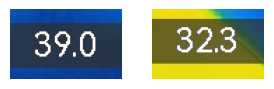

   Max Value: 39.0           |       Min Value: 32.3
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215114.jpeg


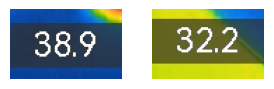

   Max Value: 38.9           |       Min Value: 32.2
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215215.jpeg


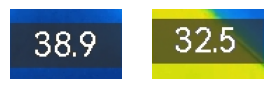

   Max Value: 38.9           |       Min Value: 32.5
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215317.jpeg


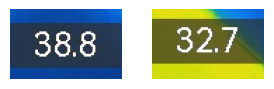

   Max Value: 38.8           |       Min Value: 32.7
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215418.jpeg


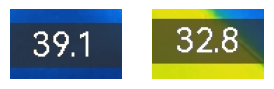

   Max Value: 39.1           |       Min Value: 32.8
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215519.jpeg


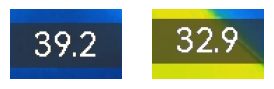

   Max Value: 39.2           |       Min Value: 32.9
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/50_02.12.24-03.12.24/HM20241202215620.jpeg


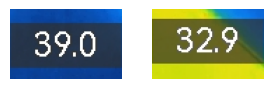

   Max Value: 39.0           |       Min Value: 32.9
----------------------------------------------------------------------------------------------------


In [37]:
for path in image_paths_horizontal[43:50]:
    all_images(path)

## Vertical:


In [50]:
folder_path_vertical = "/home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/*.jpg"

# Get a list of all image files in the folder
image_paths_vertical = sorted(glob.glob(folder_path_vertical))

print(len(image_paths_vertical)) 


7


Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240815233312_.jpg


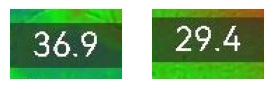

   Max Value: 36.9           |       Min Value: 29.4
Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240816005549_.jpg


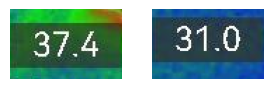

   Max Value: 37.4           |       Min Value: 31.0
Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240816011016_.jpg


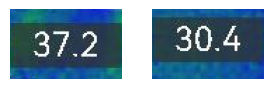

   Max Value: 37.2           |       Min Value: 30.4
Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240816030018_.jpg


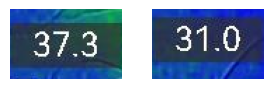

   Max Value: 37.3           |       Min Value: 31.0
Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240816050859_.jpg


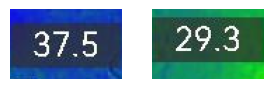

   Max Value: 37.5           |       Min Value: 29.3
Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240816065935_.jpg


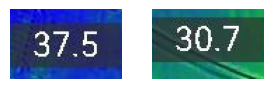

   Max Value: 37.5           |       Min Value: 30.7
Processing: /home/martina/codi2/3year/synthesisII/prova_dataset/coco_annotations/JPEGImages/HM20240816074705_.jpg


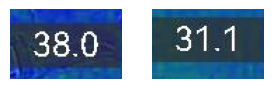

   Max Value: 38.0           |       Min Value: 31.1


In [51]:
for path in image_paths_vertical[:7]:
    all_images(path)

## Different formats and colors:

In [52]:
folder_path = "/home/martina/codi2/3year/synthesisII/diferent/*.jpeg"

# Get a list of all image files in the folder
image_paths = sorted(glob.glob(folder_path))

print(len(image_paths)) 

8


Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20240815055937.jpeg


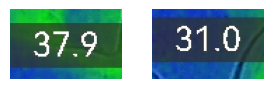

   Max Value: 37.9           |       Min Value: 31.0
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20240815062318.jpeg


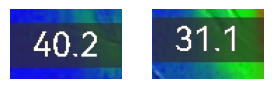

   Max Value: 40.2           |       Min Value: 31.1
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202060956.jpeg


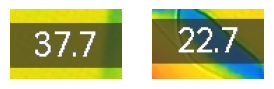

   Max Value: 37.7           |       Min Value: 22.7
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202065451.jpeg


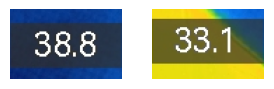

   Max Value: 38.8           |       Min Value: 33.1
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202081023.jpeg


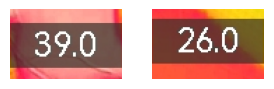

   Max Value: 39.0           |       Min Value: 26.0
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202081529.jpeg


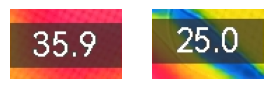

   Max Value: 35.9           |       Min Value: 25.0
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202093407.jpeg


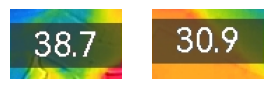

   Max Value: 38.7           |       Min Value: 30.9
----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202100444.jpeg


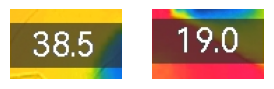

   Max Value: 38.5           |       Min Value: 19.0
----------------------------------------------------------------------------------------------------


In [42]:
for path in image_paths[:]:
    all_images(path)

# Grayscale:

Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20240815055937.jpeg
coordinates - grayscale value - temperatures:
(382, 156) - Grayscale value: 104, Temperature: 33.8
(408, 160) - Grayscale value: 118, Temperature: 34.2
(436, 293) - Grayscale value: 112, Temperature: 34.0
(425, 308) - Grayscale value: 102, Temperature: 33.8
(39, 430) - Grayscale value: 63, Temperature: 32.7
VALIDATION
Lowest pixel value: 2 at coordinates (24, 444) - Normalized temperature: 31.1
Highest pixel value: 255 at coordinates (283, 13) - Normalized temperature: 37.9


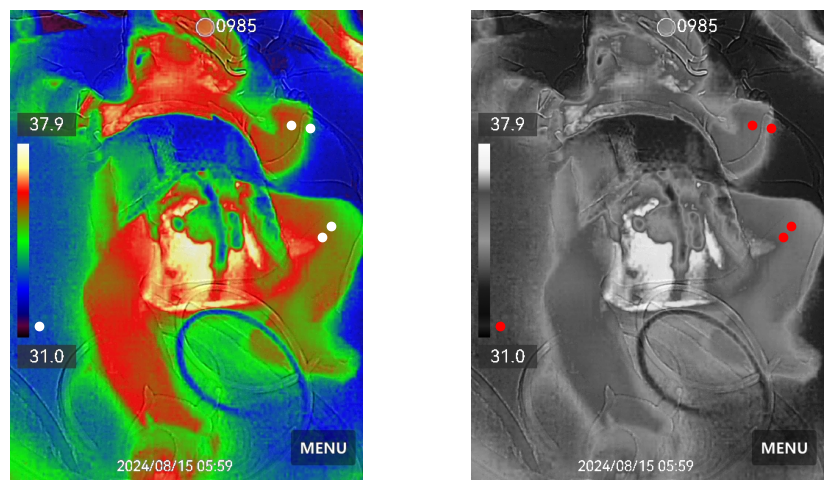

----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20240815062318.jpeg
coordinates - grayscale value - temperatures:
(350, 46) - Grayscale value: 19, Temperature: 31.8
(48, 47) - Grayscale value: 54, Temperature: 33.0
(437, 293) - Grayscale value: 70, Temperature: 33.6
(258, 557) - Grayscale value: 75, Temperature: 33.8
(265, 582) - Grayscale value: 54, Temperature: 33.0
VALIDATION
Lowest pixel value: 2 at coordinates (12, 444) - Normalized temperature: 31.2
Highest pixel value: 255 at coordinates (288, 13) - Normalized temperature: 40.2


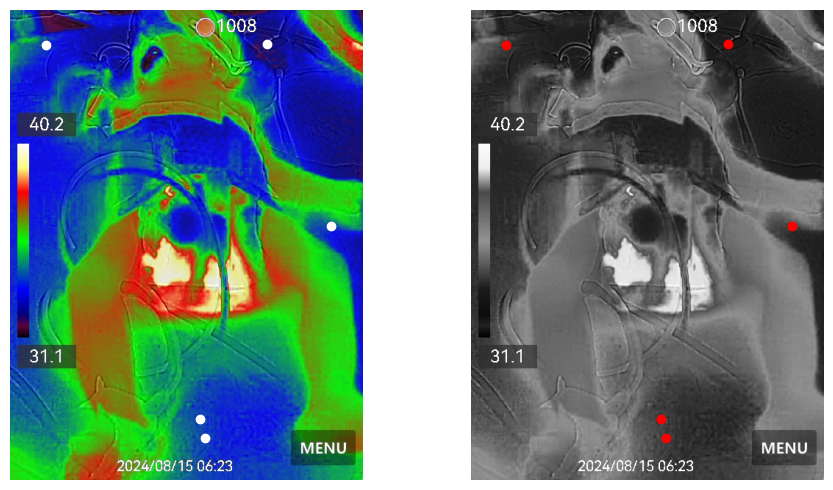

----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202060956.jpeg
coordinates - grayscale value - temperatures:
(205, 29) - Grayscale value: 99, Temperature: 28.5
(417, 57) - Grayscale value: 73, Temperature: 27.0
(271, 263) - Grayscale value: 105, Temperature: 28.9
(581, 406) - Grayscale value: 199, Temperature: 34.4
(323, 415) - Grayscale value: 203, Temperature: 34.6
VALIDATION
Lowest pixel value: 9 at coordinates (14, 379) - Normalized temperature: 23.2
Highest pixel value: 255 at coordinates (30, 147) - Normalized temperature: 37.7


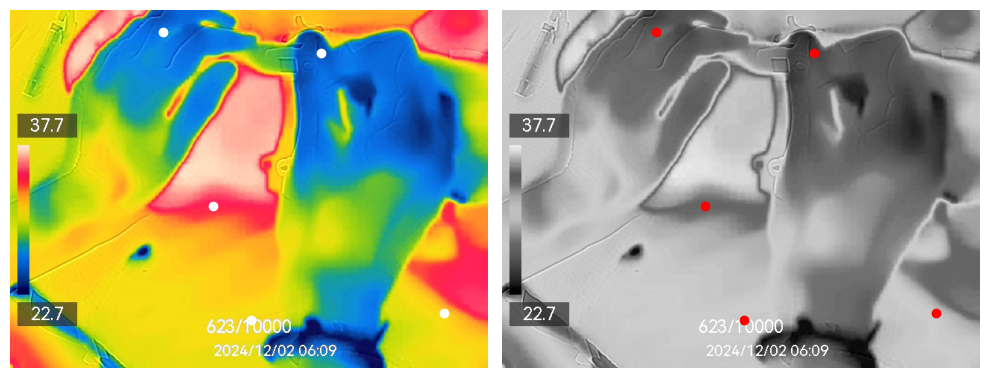

----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202065451.jpeg
coordinates - grayscale value - temperatures:
(106, 152) - Grayscale value: 80, Temperature: 34.9
(130, 165) - Grayscale value: 187, Temperature: 37.3
(228, 346) - Grayscale value: 148, Temperature: 36.4
(35, 429) - Grayscale value: 201, Temperature: 37.6
(168, 469) - Grayscale value: 111, Temperature: 35.6
VALIDATION
Lowest pixel value: 9 at coordinates (12, 377) - Normalized temperature: 33.3
Highest pixel value: 255 at coordinates (31, 146) - Normalized temperature: 38.8


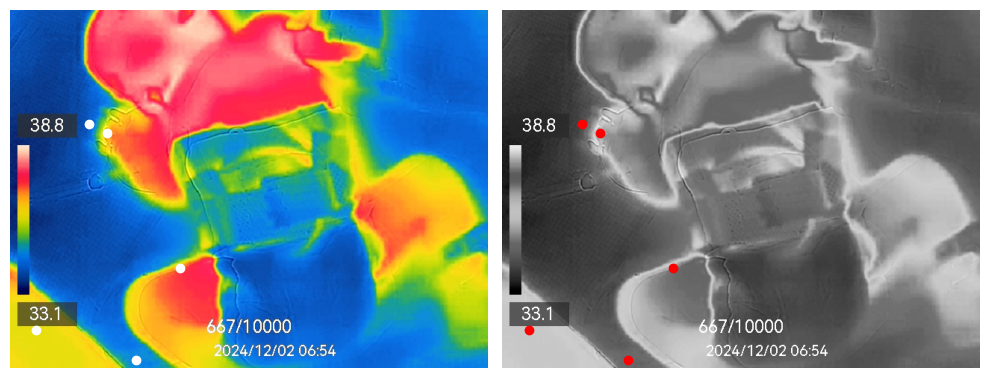

----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202081023.jpeg
coordinates - grayscale value - temperatures:
(72, 143) - Grayscale value: 91, Temperature: 30.6
(136, 295) - Grayscale value: 199, Temperature: 36.1
(241, 370) - Grayscale value: 205, Temperature: 36.5
(628, 425) - Grayscale value: 194, Temperature: 35.9
(392, 478) - Grayscale value: 201, Temperature: 36.2
VALIDATION
Lowest pixel value: 9 at coordinates (24, 380) - Normalized temperature: 26.5
Highest pixel value: 255 at coordinates (30, 147) - Normalized temperature: 39.0


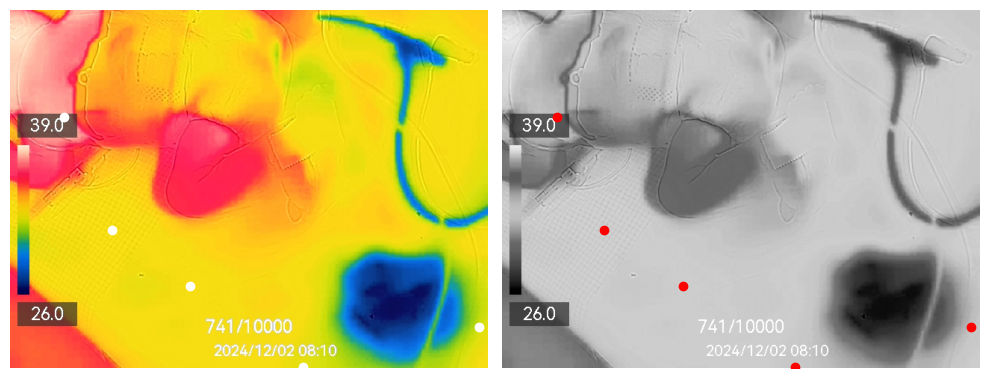

----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202081529.jpeg
coordinates - grayscale value - temperatures:
(145, 179) - Grayscale value: 122, Temperature: 30.2
(441, 243) - Grayscale value: 149, Temperature: 31.4
(223, 379) - Grayscale value: 171, Temperature: 32.3
(594, 447) - Grayscale value: 203, Temperature: 33.7
(635, 460) - Grayscale value: 196, Temperature: 33.4
VALIDATION
Lowest pixel value: 9 at coordinates (299, 103) - Normalized temperature: 25.4
Highest pixel value: 255 at coordinates (35, 149) - Normalized temperature: 35.9


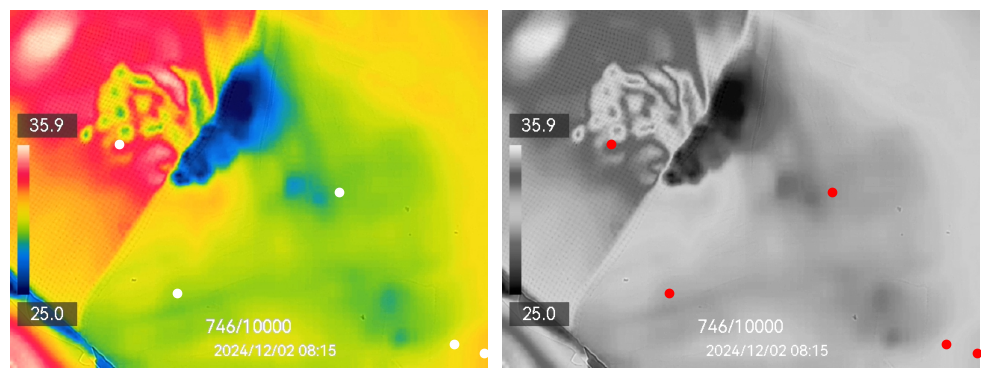

----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202093407.jpeg
coordinates - grayscale value - temperatures:
(537, 150) - Grayscale value: 115, Temperature: 34.4
(200, 230) - Grayscale value: 208, Temperature: 37.3
(595, 252) - Grayscale value: 111, Temperature: 34.3
(48, 430) - Grayscale value: 180, Temperature: 36.4
(113, 435) - Grayscale value: 174, Temperature: 36.2
VALIDATION
Lowest pixel value: 7 at coordinates (79, 10) - Normalized temperature: 31.1
Highest pixel value: 255 at coordinates (31, 147) - Normalized temperature: 38.7


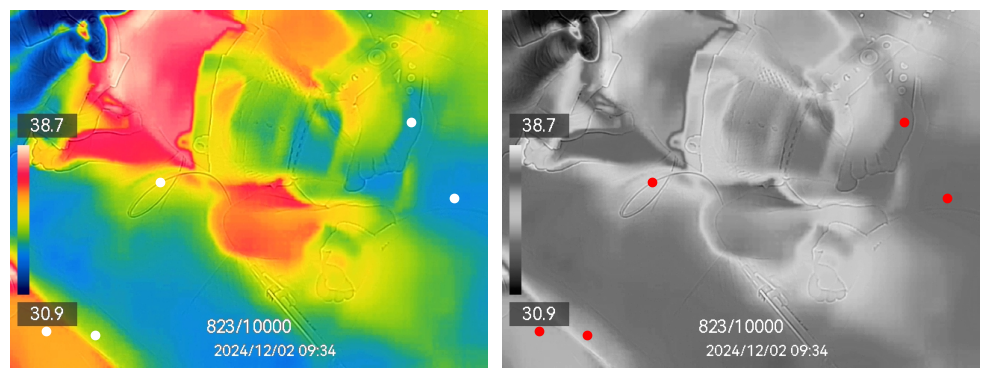

----------------------------------------------------------------------------------------------------
Processing: /home/martina/codi2/3year/synthesisII/diferent/HM20241202100444.jpeg
coordinates - grayscale value - temperatures:
(234, 130) - Grayscale value: 184, Temperature: 33.1
(329, 245) - Grayscale value: 180, Temperature: 32.8
(70, 311) - Grayscale value: 23, Temperature: 20.8
(168, 315) - Grayscale value: 132, Temperature: 29.1
(518, 466) - Grayscale value: 200, Temperature: 34.3
VALIDATION
Lowest pixel value: 9 at coordinates (71, 293) - Normalized temperature: 19.7
Highest pixel value: 255 at coordinates (44, 147) - Normalized temperature: 38.5


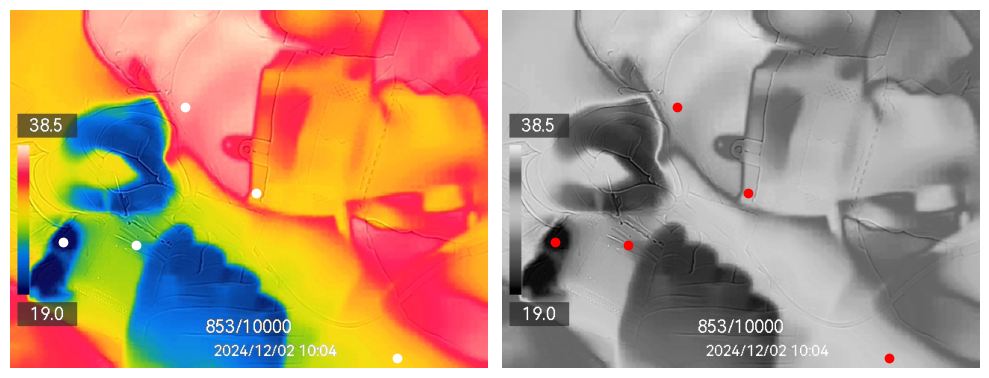

----------------------------------------------------------------------------------------------------


In [ ]:
def normalize(value, min_val, max_val, new_min, new_max):
    """Min-max scaling function"""
    return new_min + (value - min_val) * (new_max - new_min) / (max_val - min_val)

def get_average_in_window(image, center_x, center_y, window_size=3):
    # This function is to ensure we are not getting specific points where the color is one but the region is another, so we are getting stable temperatures
    # (almost invisible to the naked eye, it will be a small window)
    
    half_window = window_size // 2
    # Ensure that the window is within the image bounds
    x1 = max(center_x - half_window, 0)
    x2 = min(center_x + half_window, image.shape[1] - 1)
    y1 = max(center_y - half_window, 0)
    y2 = min(center_y + half_window, image.shape[0] - 1)
    
    # Extract the window and calculate the average pixel value
    window = image[y1:y2+1, x1:x2+1]
    average_pixel_value = np.mean(window)
    return int(average_pixel_value)

def check_correlation(path):   
        image = cv2.imread(path)
        if image is None:
            print(f"Error loading image: {path}")
            return
        
        grayscale_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        
        max_temp, min_temp = all_images(path, plot=False) # Get the max and min values from the image
        
        #select 5 random points in the image
        points = []
        for _ in range(5):
            x = random.randint(0, grayscale_image.shape[1] - 1)
            y = random.randint(0, grayscale_image.shape[0] - 1)
            points.append((x, y))
        
        # Get the pixel values at the selected points
        #pixel_values = [grayscale_image[y, x] for x, y in points]
        
        window_size = 3  # You can adjust this size
        pixel_values = [get_average_in_window(grayscale_image, x, y, window_size) for x, y in points]

        # Normalize the pixel values
        temperatures = [normalize(value, 0, 255, min_temp, max_temp) for value in pixel_values]
        
        sorted_points = sorted(zip(points, pixel_values, temperatures), key=lambda p: (p[0][1], p[0][0]))

        
        # print the pixel values and the normalized values
        print("coordinates - grayscale value - temperatures:")
        for (x, y), pixel, temp in sorted_points:
            print(f"({x}, {y}) - Grayscale value: {pixel}, Temperature: {temp:.1f}")
        
        ################################## VALIDATION ######################################
        
        # Find the pixel with the highest and lowest grayscale values
        min_pixel_location = np.unravel_index(np.argmin(grayscale_image), grayscale_image.shape)
        max_pixel_location = np.unravel_index(np.argmax(grayscale_image), grayscale_image.shape)

        min_pixel_value = grayscale_image[min_pixel_location]
        max_pixel_value = grayscale_image[max_pixel_location]

        # Normalize the lowest and highest pixel values to the temperature range
        min_temp_from_pixel = normalize(min_pixel_value, 0, 255, min_temp, max_temp)
        max_temp_from_pixel = normalize(max_pixel_value, 0, 255, min_temp, max_temp)

        # Print the lowest and highest pixel values, their coordinates, and the normalized temperature values
        print("VALIDATION")
        print(f"Lowest pixel value: {min_pixel_value} at coordinates ({min_pixel_location[1]}, {min_pixel_location[0]}) - Normalized temperature: {min_temp_from_pixel:.1f}")
        print(f"Highest pixel value: {max_pixel_value} at coordinates ({max_pixel_location[1]}, {max_pixel_location[0]}) - Normalized temperature: {max_temp_from_pixel:.1f}")

        ################################## VALIDATION ######################################
        
        # Plot the thermal and grayscale images marking the selected points
        plt.figure(figsize=(10, 5))  # Adjust size for better visualization
        plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        for x, y in points:
            plt.plot(x, y, "wo")  # Mark the selected points with red circles          
        plt.axis("off")
        
        plt.subplot(1, 2, 2)  # 1 row, 2 columns, second subplot
        plt.imshow(grayscale_image, cmap="gray")
        for x, y in points:
            plt.plot(x, y, "ro")  # Mark the selected points with red circles
        plt.axis("off")
        
        plt.tight_layout()
        plt.show()
    
        print("-" * 100)  # Separator for readability

        
        
for path in image_paths[:]:
    check_correlation(path)

We have noticed that the points with red color give lower temperatures than they should:

The color mapping from the thermal image might cause some issues when translating it to grayscale because the color-to-grayscale translation does not preserve the same temperature order


thermal image from hottest temperature to lowest are: white, red, orange, yellow, green, blue, purple/black. 
ordered colors in grayscale from darkest to whitest: black, blue, red, magenta, gray, green, cyan, yellow, white